# External Noisy Data Without Initial Conditions -fixed weights
---
In this experiment, a PINN was trained using sparse external data (30 points per trajectory) corrupted with (20%) noise. ***Unlike previous experiments, the network was not provided with the initial conditions*** and only had access to the governing differential equations and the noisy observations.


**Key Features**

* External noisy data generated from Lagrange orbits.
* No initial conditions were provided to the network.
* Output-layer biases were initialized to different values to avoid singularities arising from symmetric initial predictions.

**Important Observation**

Although no initial conditions were provided, the PINN reconstructs a solution in which the three bodies form an approximately equilateral triangle. This suggests that the governing equations and the noisy observations contain enough information to recover the geometric structure of the Lagrange orbit.






In [6]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

## IMPORTS

In [9]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

# Training

In [10]:
dde.config.set_default_float("float64")

seed=137
np.random.seed(seed)
tf.random.set_seed(seed)
dde.config.set_random_seed(seed)

# ============================================================
# Constants
# ============================================================
scale = 2
G = 1.0
m = [1.0, 1.0, 1.0]
periods=1
endTime =periods * (4 / scale**3)


num_domain = 64
num_boundary = 12
num_test = 100


layer_size = [1] + [64]*3 + [6]
activation = "tanh"
initializer = "Glorot uniform" #"Glorot uniform" #"He normal" #

iterations =150000
learning_rate = 1e-4
loss_weights=[0.1]*6+[10]*6
#optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0001,weight_decay=0.0004)


eps = 1e-9   #softening factor for gravity low

# ============================================================
# Initial Conditions
# ============================================================
omega = 0.3

x1_0, y1_0 = -1.0/scale**2, 0.0/scale**2
x2_0, y2_0 =  1.0/scale**2, 0.0/scale**2
x3_0, y3_0 =  0.0/scale**2, np.sqrt(3)/scale**2

vx1_0, vy1_0 = (-np.sqrt(3)/3)*omega*scale, 1*omega*scale
vx2_0, vy2_0 = (-np.sqrt(3)/3)*omega*scale, -1*omega*scale
vx3_0, vy3_0 = (2*np.sqrt(3)/3)*omega*scale, 0

y0 = np.array([x1_0,y1_0,x2_0,y2_0,x3_0,y3_0])
v0 = np.array([vx1_0,vy1_0,vx2_0,vy2_0,vx3_0,vy3_0])

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)

# ============================================================
# NUMERICAL SOLUTION (for synthetic measurements)
# ============================================================

def three_body_numeric(t, y):

    x1,y1,vx1,vy1,x2,y2,vx2,vy2,x3,y3,vx3,vy3 = y

    r12 = np.sqrt((x1-x2)**2 + (y1-y2)**2 +eps)
    r13 = np.sqrt((x1-x3)**2 + (y1-y3)**2 +eps)
    r23 = np.sqrt((x2-x3)**2 + (y2-y3)**2 +eps)

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    return [vx1,vy1,ax1,ay1,
            vx2,vy2,ax2,ay2,
            vx3,vy3,ax3,ay3]


t_span = (0,endTime)
t_eval = np.linspace(0,endTime,5000)

y0_full = [
x1_0,y1_0,vx1_0,vy1_0,
x2_0,y2_0,vx2_0,vy2_0,
x3_0,y3_0,vx3_0,vy3_0
]

sol = solve_ivp(three_body_numeric,t_span,y0_full,
                t_eval=t_eval,rtol=1e-10,atol=1e-12)

x1_n,y1_n = sol.y[0],sol.y[1]
x2_n,y2_n = sol.y[4],sol.y[5]
x3_n,y3_n = sol.y[8],sol.y[9]

# ============================================================
# SYNTHETIC NOISY MEASUREMENTS
# ============================================================

num_obs = 30
noise_level = 0.1

idx = np.sort(np.random.choice(len(t_eval),num_obs,replace=False))

t_obs = t_eval[idx][:,None]

y_obs_true = np.vstack([
x1_n[idx],y1_n[idx],
x2_n[idx],y2_n[idx],
x3_n[idx],y3_n[idx]
]).T

noise = noise_level*np.std(y_obs_true,axis=0)*np.random.randn(*y_obs_true.shape)

y_obs = y_obs_true + noise

# ============================================================
# PINN PDE
# ============================================================

def three_body_ode_second(t,y):

    x1,y1,x2,y2,x3,y3 = [y[:,i:i+1] for i in range(6)]

    r12 = tf.sqrt((x1-x2)**2 + (y1-y2)**2 +eps)
    r13 = tf.sqrt((x1-x3)**2 + (y1-y3)**2 +eps)
    r23 = tf.sqrt((x2-x3)**2 + (y2-y3)**2 +eps)

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    x1_tt = dde.grad.hessian(y,t,component=0,i=0,j=0)
    y1_tt = dde.grad.hessian(y,t,component=1,i=0,j=0)
    x2_tt = dde.grad.hessian(y,t,component=2,i=0,j=0)
    y2_tt = dde.grad.hessian(y,t,component=3,i=0,j=0)
    x3_tt = dde.grad.hessian(y,t,component=4,i=0,j=0)
    y3_tt = dde.grad.hessian(y,t,component=5,i=0,j=0)

    return [
        (x1_tt-ax1),
        (y1_tt-ay1),
        (x2_tt-ax2),
        (y2_tt-ay2),
        (x3_tt-ax3),
        (y3_tt-ay3)
    ]

# ============================================================
# Geometry
# ============================================================

geom = dde.geometry.TimeDomain(0,endTime)

# observation constraints
observe_x1 = dde.PointSetBC(t_obs,y_obs[:,0:1],component=0)
observe_y1 = dde.PointSetBC(t_obs,y_obs[:,1:2],component=1)
observe_x2 = dde.PointSetBC(t_obs,y_obs[:,2:3],component=2)
observe_y2 = dde.PointSetBC(t_obs,y_obs[:,3:4],component=3)
observe_x3 = dde.PointSetBC(t_obs,y_obs[:,4:5],component=4)
observe_y3 = dde.PointSetBC(t_obs,y_obs[:,5:6],component=5)

data = dde.data.PDE(
geom,
three_body_ode_second,
[ observe_x1,observe_y1,observe_x2,observe_y2,observe_x3,observe_y3],
num_domain=num_domain,
num_boundary=num_boundary,
num_test=num_test
)

# ============================================================
# NETWORK
# ============================================================

net = dde.nn.FNN(layer_size,activation,initializer)


model = dde.Model(data,net)

#model.compile(optimizer=optimizer)
model.compile("adam",lr=learning_rate,loss_weights=loss_weights)

###############################################################
# Change bias in last layer to avoid xero outputs at t=0
###############################################################
model.predict([[0.0]])   #dummy presict to create model.. tensorflow behaviour
# modify bias
last_layer=3
model.net.summary()
last_layer = model.net.layers[last_layer]   # dense_3
w, b = last_layer.get_weights()
print("old bias:", b)
b = np.array([-0.2, 0.2, 0, 0, 0.2, -0.2])   # out bias separation to avoid very high pde losses at the start of training
last_layer.set_weights([w, b])
print("new bias:", b)
##############################################################
##############################################################


losshistory,train_state = model.train(iterations=iterations)

#model.compile("L-BFGS")
#losshistory,train_state = model.train()

Set the default float type to float64
Compiling model...
'compile' took 0.009957 s



Model: "fnn_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (1, 64)                │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (1, 64)                │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (1, 6)                 │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,838 (69.05 KB)

 Trainable params: 8,838 (69.05 KB)

 Non-trainable params: 0 (0.00 B)

old bias: [0. 0. 0. 0. 0. 0.]
new bias: [-0.2  0.2  0.   0.   0.2 -0.2]
Training model...

Step      Train loss                                                                                                                  Test loss                                                                                                                   Test metric
0         [1.75e+01, 6.10e+01, 1.46e+00, 2.51e+01, 9.56e+00, 1.07e+01, 8.14e-02, 2.86e-01, 3.58e-01, 7.84e-02, 4.64e-01, 2.62e+00]    [1.83e+01, 5.42e+01, 1.62e+00, 2.01e+01, 9.60e+00, 1.07e+01, 8.14e-02, 2.86e-01, 3.58e-01, 7.84e-02, 4.64e-01, 2.62e+00]    []  
1000      [1.25e+00, 1.26e-01, 1.89e-02, 6.32e-02, 1.55e+00, 7.41e-02, 1.90e+00, 5.62e-01, 3.03e-01, 7.24e-02, 3.11e+00, 7.67e-01]    [1.25e+00, 1.26e-01, 2.15e-02, 5.64e-02, 1.58e+00, 6.78e-02, 1.90e+00, 5.62e-01, 3.03e-01, 7.24e-02, 3.11e+00, 7.67e-01]    []  
2000      [5.35e-01, 1.58e-01, 3.61e-01, 2.81e-01, 5.55e-02, 5.53e-01, 7.79e-01, 2.01e-01, 6.38e-01, 3.22e-01, 1.

#Plots -Results

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


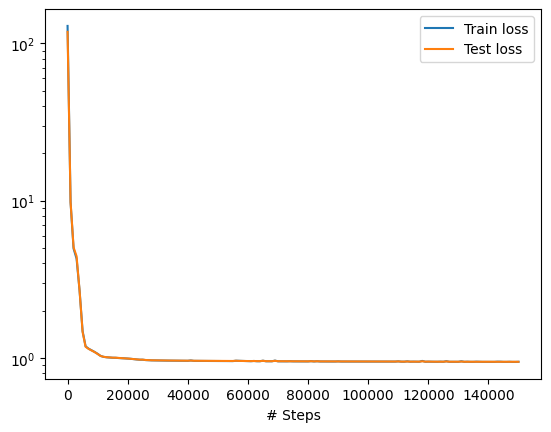

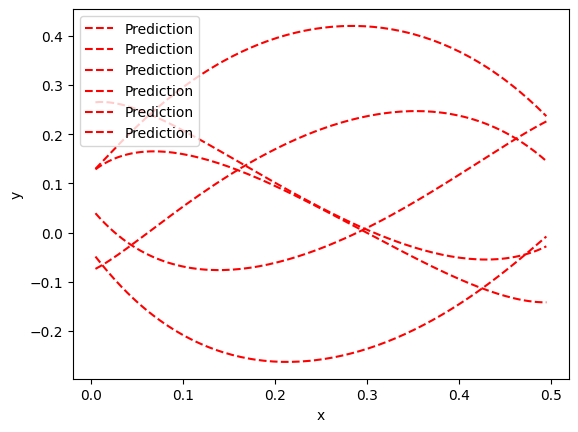

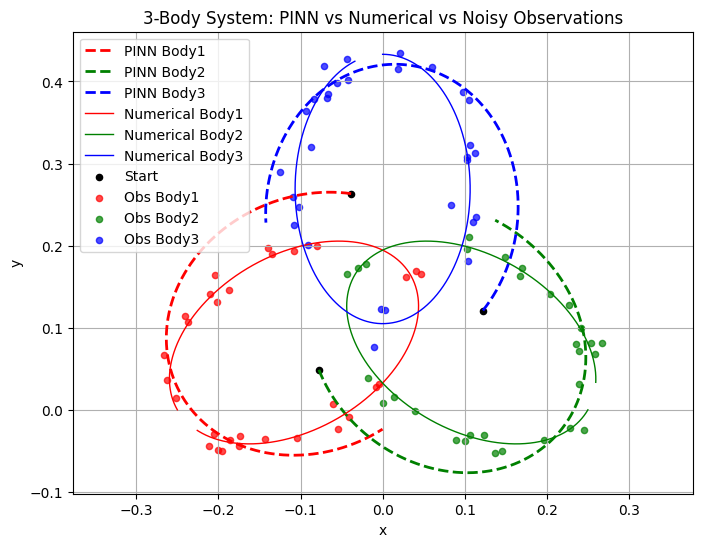

length-12  0.2181175920504326
length-13  0.21449322441844335
length-23  0.21243235816977638

--- L2 Relative Errors ---
Body 1 x error: 8.04e-01
Body 1 y error: 1.15e+00
Body 2 x error: 8.78e-01
Body 2 y error: 9.62e-01
Body 3 x error: 9.35e-01
Body 3 y error: 5.06e-01


In [12]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)


# ============================================================
# PINN PREDICTION
# ============================================================

t_test = np.linspace(0,endTime,5000)[:,None]

y_pred = model.predict(t_test)

x1,y1 = y_pred[:,0],y_pred[:,1]
x2,y2 = y_pred[:,2],y_pred[:,3]
x3,y3 = y_pred[:,4],y_pred[:,5]

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(x1,y1,'r--',lw=2,label="PINN Body1")
plt.plot(x2,y2,'g--',lw=2,label="PINN Body2")
plt.plot(x3,y3,'b--',lw=2,label="PINN Body3")

plt.plot(x1_n,y1_n,'r-',lw=1,label="Numerical Body1")
plt.plot(x2_n,y2_n,'g-',lw=1,label="Numerical Body2")
plt.plot(x3_n,y3_n,'b-',lw=1,label="Numerical Body3")

#starting points
plt.scatter([x1[0], x2[0], x3[0]],
            [y1[0], y2[0], y3[0]],
            color='k', marker='o', s=20, label='Start')

# noisy measurements
plt.scatter(y_obs[:,0],y_obs[:,1],c='red',s=20,alpha=0.7,label="Obs Body1")
plt.scatter(y_obs[:,2],y_obs[:,3],c='green',s=20,alpha=0.7,label="Obs Body2")
plt.scatter(y_obs[:,4],y_obs[:,5],c='blue',s=20,alpha=0.7,label="Obs Body3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.title("3-Body System: PINN vs Numerical vs Noisy Observations")

plt.show()


#============================================
# DISTANCE OF INITAL POTITIONS
#=============================================

len12=np.sqrt((x1[0]-x2[0])**2 +(y1[0]-y2[0])**2 )
len13=np.sqrt((x1[0]-x3[0])**2 +(y1[0]-y3[0])**2 )
len23=np.sqrt((x2[0]-x3[0])**2 +(y2[0]-y3[0])**2 )
print("length-12 ",len12)
print("length-13 ",len13)
print("length-23 ",len23)




# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")

#STATISTICS

In [13]:
# ============================================================
# STATISTICS
# ============================================================


print("\n")
print("="*60)
print("STATISTICS")
print("="*60)

# ============================================================
# PINN velocities from automatic differentiation
# ============================================================

t_tf = tf.convert_to_tensor(t_test, dtype=tf.float64)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred_tf = model.net(t_tf)

dy_dt = tape.batch_jacobian(y_pred_tf, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:, :, 0].numpy()

# PINN positions
y_pred = y_pred_tf.numpy()

x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1, vy1 = dy_dt[:,0], dy_dt[:,1]
vx2, vy2 = dy_dt[:,2], dy_dt[:,3]
vx3, vy3 = dy_dt[:,4], dy_dt[:,5]

# ============================================================
# Numerical solution
# ============================================================

x1_n  = sol.y[0]
y1_n  = sol.y[1]
vx1_n = sol.y[2]
vy1_n = sol.y[3]

x2_n  = sol.y[4]
y2_n  = sol.y[5]
vx2_n = sol.y[6]
vy2_n = sol.y[7]

x3_n  = sol.y[8]
y3_n  = sol.y[9]
vx3_n = sol.y[10]
vy3_n = sol.y[11]

# ============================================================
# TRAIN / TEST LOSS
# ============================================================

train_losses = np.array(losshistory.loss_train)
test_losses  = np.array(losshistory.loss_test)

final_train_loss = np.sum(train_losses[-1])
final_test_loss  = np.sum(test_losses[-1])

# six PDE residuals
LPDE = np.sum(train_losses[-1][:6])

# six observation losses
LDATA = np.sum(train_losses[-1][6:])

print(f"Final Training Loss : {final_train_loss:.2e}")
print(f"Final Test Loss     : {final_test_loss:.2e}")
print(f"PDE Residual Loss   : {LPDE:.2e}")
print(f"Data Loss           : {LDATA:.2e}")

# ============================================================
# 2. POSITION ERRORS - RMSE
# ============================================================

err1 = np.sqrt((x1 - x1_n)**2 + (y1 - y1_n)**2)
err2 = np.sqrt((x2 - x2_n)**2 + (y2 - y2_n)**2)
err3 = np.sqrt((x3 - x3_n)**2 + (y3 - y3_n)**2)

rmse1 = np.sqrt(np.mean(err1**2))
rmse2 = np.sqrt(np.mean(err2**2))
rmse3 = np.sqrt(np.mean(err3**2))

RMSE = np.sqrt(np.mean(
    np.concatenate([
        err1**2,
        err2**2,
        err3**2
    ])
))

print("\nPosition RMSE")
print("-----------------------------")
print(f"Body 1 : {rmse1:.2e}")
print(f"Body 2 : {rmse2:.2e}")
print(f"Body 3 : {rmse3:.2e}")
print(f"Global : {RMSE:.2e}")

print("\nMaximum Position Error")
print("-----------------------------")
print(f"Body 1 : {np.max(err1):.2e}")
print(f"Body 2 : {np.max(err2):.2e}")
print(f"Body 3 : {np.max(err3):.2e}")

max_pos_error = max(
    np.max(err1),
    np.max(err2),
    np.max(err3)
)
print(f"Global Max Position error : {max_pos_error:.2e}")

# ============================================================
# 3. ENERGY
# ============================================================



def total_energy(x1,y1,vx1,vy1,
                 x2,y2,vx2,vy2,
                 x3,y3,vx3,vy3,
                 G=1.0,
                 m=(1.0,1.0,1.0),
                 eps=0.0):

    KE = (
        0.5*m[0]*(vx1**2+vy1**2)
        +0.5*m[1]*(vx2**2+vy2**2)
        +0.5*m[2]*(vx3**2+vy3**2)
    )

    r12 = np.sqrt((x1-x2)**2+(y1-y2)**2+eps)
    r13 = np.sqrt((x1-x3)**2+(y1-y3)**2+eps)
    r23 = np.sqrt((x2-x3)**2+(y2-y3)**2+eps)

    PE = (
        -G*m[0]*m[1]/r12
        -G*m[0]*m[2]/r13
        -G*m[1]*m[2]/r23
    )

    return KE + PE


E = total_energy(
    x1,y1,vx1,vy1,
    x2,y2,vx2,vy2,
    x3,y3,vx3,vy3,
    G,m,eps
)

E0 = E[0]

DE_E0 = np.max(np.abs(E-E0))/abs(E0)

print("\nEnergy Conservation")
print("-----------------------------")
print(f"PINN ΔE/E0 : {DE_E0:.2e}")

E_num = total_energy(
    x1_n, y1_n, vx1_n, vy1_n,
    x2_n, y2_n, vx2_n, vy2_n,
    x3_n, y3_n, vx3_n, vy3_n,
    G, m, eps
)

E0_num = E_num[0]

DE_E0_num = np.max(np.abs(E_num-E0_num))/abs(E0_num)


print("-----------------------------")
print(f"Numerical ΔE/E0 : {DE_E0_num:.2e}")

# ============================================================
# 4. LINEAR MOMENTUM DRIFT
# ============================================================

Px = m[0]*vx1 + m[1]*vx2 + m[2]*vx3
Py = m[0]*vy1 + m[1]*vy2 + m[2]*vy3

DeltaP = np.max(
    np.sqrt(
        (Px - Px[0])**2 +
        (Py - Py[0])**2
    )
)

print("\nLinear Momentum")
print("-----------------------------")
print(f"PINN Max Momentum Drift : {DeltaP:.2e}")

Px_n = m[0]*vx1_n + m[1]*vx2_n + m[2]*vx3_n
Py_n = m[0]*vy1_n + m[1]*vy2_n + m[2]*vy3_n

DeltaP_n = np.max(
    np.sqrt(
        (Px_n - Px_n[0])**2 +
        (Py_n - Py_n[0])**2
    )
)


print("-----------------------------")
print(f"Numerical Max Momentum Drift : {DeltaP_n:.2e}")


# ============================================================
# 5. ANGULAR MOMENTUM
# ============================================================

L = (
      m[0]*(x1*vy1-y1*vx1)
    + m[1]*(x2*vy2-y2*vx2)
    + m[2]*(x3*vy3-y3*vx3)
)

L0 = L[0]

DL_L0 = np.max(np.abs(L-L0))/max(abs(L0),1e-15)

print("\nAngular Momentum Conservation")
print("-----------------------------")
print(f"ΔL/L0 : {DL_L0:.2e}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print(f"Final Training Loss               : {final_train_loss:.2e}")
print(f"Final Test Loss                   : {final_test_loss:.2e}")
print(f"PDE Residual Loss                 : {LPDE:.2e}")
print(f"Data Loss                         : {LDATA:.2e}")
print(f"Global Max Position error         : {max_pos_error:.2e}")
print(f"Position RMSE                     : {RMSE:.2e}")
print(f"PINN ΔE/E0                        : {DE_E0:.2e}")
print(f"Numerical ΔE/E0                   : {DE_E0_num:.2e}")
print(f"PINN Max Momentum Drift ΔP        : {DeltaP:.2e}")
print(f"Numerical Max Momentum Drift ΔP   : {DeltaP_n:.2e}")
print(f"ΔL/L0                             : {DL_L0:.2e}")



STATISTICS
Final Training Loss : 9.47e-01
Final Test Loss     : 9.47e-01
PDE Residual Loss   : 1.09e-02
Data Loss           : 9.36e-01

Position RMSE
-----------------------------
Body 1 : 1.85e-01
Body 2 : 1.84e-01
Body 3 : 1.85e-01
Global : 1.85e-01

Maximum Position Error
-----------------------------
Body 1 : 3.38e-01
Body 2 : 3.31e-01
Body 3 : 3.35e-01
Global Max Position error : 3.38e-01

Energy Conservation
-----------------------------
PINN ΔE/E0 : 2.15e-02
-----------------------------
Numerical ΔE/E0 : 9.48e-10

Linear Momentum
-----------------------------
PINN Max Momentum Drift : 6.33e-03
-----------------------------
Numerical Max Momentum Drift : 4.93e-15

Angular Momentum Conservation
-----------------------------
ΔL/L0 : 1.39e-02


SUMMARY
Final Training Loss               : 9.47e-01
Final Test Loss                   : 9.47e-01
PDE Residual Loss                 : 1.09e-02
Data Loss                         : 9.36e-01
Global Max Position error         : 3.38e-01
Positi